In [31]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from darts import TimeSeries
from darts.ad import (
    ForecastingAnomalyModel,
    KMeansScorer,
    NormScorer,
    WassersteinScorer
)

from darts.ad.utils import (
    eval_metric_from_scores,
    show_anomalies_from_scores
)

from darts.dataprocessing.transformers import Scaler
from darts.datasets import TaxiNewYorkDataset
from darts.metrics import mae, rmse
from darts.models import RegressionModel

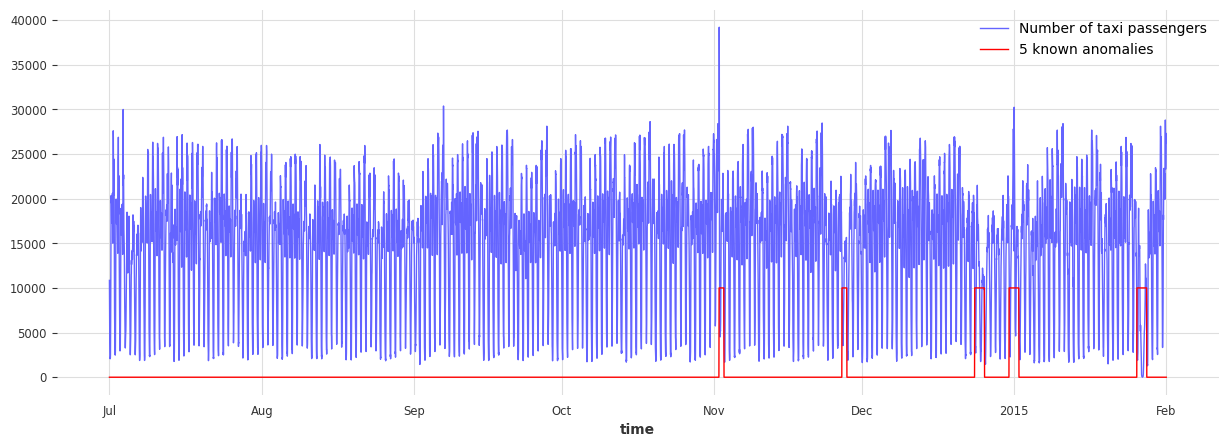

In [33]:
series_taxi = TaxiNewYorkDataset().load()

anomalies_day = {
    "NYC Marathon": ("2014-11-02 00:00", "2014-11-02 23:30"),
    "Thanksgiving": ("2014-11-27 00:00", "2014-11-27 23:30"),
    "Christmas": ("2014-12-24 00:00", "2014-12-25 23:30"),
    "New Years": ("2014-12-31 00:00", "2015-01-01 23:30"),
    "Snow Blizzard": ("2015-01-26 00:00", "2015-01-27 23:30")
}

anomalies_day = {
    k:  (pd.Timestamp(v[0]), pd.Timestamp(v[1]) ) for k,v in anomalies_day.items()
}

anomalies = pd.Series([0] * len(series_taxi), index=series_taxi.time_index)
for start, end in anomalies_day.values():
    anomalies.loc[(start <= anomalies.index) & (anomalies.index <= end)] = 1.0

series_taxi_anomalies = TimeSeries.from_series(anomalies)

fig, ax = plt.subplots(figsize=(15, 5))
series_taxi.plot(label="Number of taxi passengers", linewidth=1, color="#6464ff")
(series_taxi_anomalies * 10000).plot(label="5 known anomalies", color="r", linewidth=1)
plt.show()

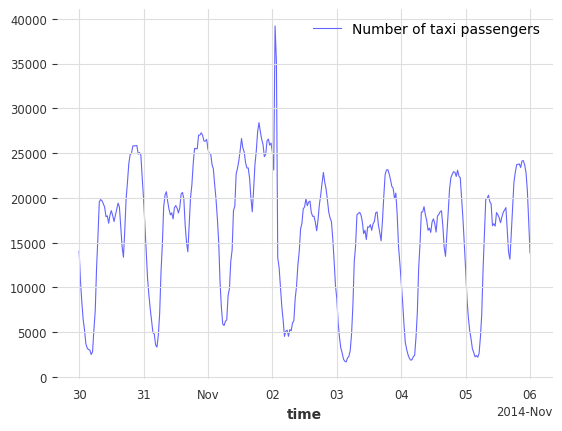

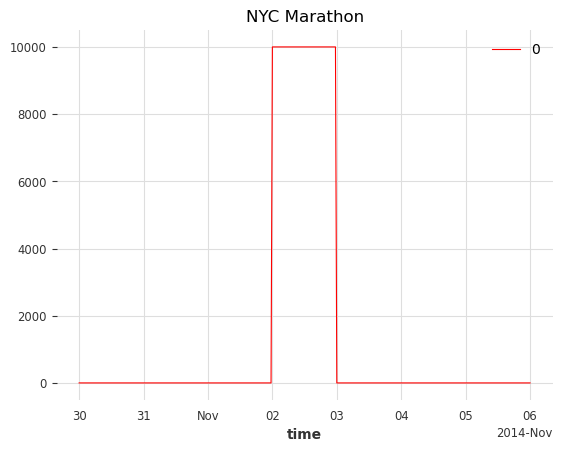

In [34]:
def plot_anom(selected_anomaly, delta_plotted_days):
    one_day = series_taxi.freq * 24 * 2
    anomaly_date = anomalies_day[selected_anomaly][0]
    start_timestamp = anomaly_date - delta_plotted_days * one_day
    end_timestamp = anomaly_date + (delta_plotted_days + 1) * one_day

    series_taxi[start_timestamp:end_timestamp].plot(
        label="Number of taxi passengers", color="#6464ff", linewidth=0.8, zorder=1
    )

    (series_taxi_anomalies[start_timestamp:end_timestamp] * 10000).plot(
        "label=Known anomaly", color="r", linewidth=0.8, zorder=2
    )
    plt.title(selected_anomaly)
    plt.show()

for anom_name in anomalies_day:
    plot_anom(anom_name, 3)
    break

In [35]:
s_taxi_train = series_taxi[:4500]
s_taxi_test = series_taxi[4500:]

add_encoders = {
    "cyclic": {"future": ["hour", "dayofweek"]}
}

one_week = 7*24*2 # one week in 30min units

forecasting_model = RegressionModel(
    lags=one_week,
    lags_future_covariates=[0],
    output_chunk_length=1,
    add_encoders=add_encoders
)
forecasting_model.fit(s_taxi_train)

RegressionModel(lags=336, lags_past_covariates=None, lags_future_covariates=[0], output_chunk_length=1, output_chunk_shift=0, add_encoders={'cyclic': {'future': ['hour', 'dayofweek']}}, model=None, multi_models=True, use_static_covariates=True)

In [36]:
# using units of 30min
half_a_day = 2*12
full_day = 2*24

# anomaly model composed of: one fitted model and 3 scorers
anomaly_model = ForecastingAnomalyModel(
    model=forecasting_model,
    scorer=[
        NormScorer(ord=1),
        WassersteinScorer(window=half_a_day, window_agg=False),
        WassersteinScorer(window=full_day, window_agg=True)
    ]
)

In [37]:
START = 0.1
anomaly_model.fit(s_taxi_train, start=START, allow_model_training=False, verbose=True)

historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]

In [38]:
anomaly_scores, model_forecasting = anomaly_model.score(
    s_taxi_test, start=START, return_model_prediction=True, verbose=True
)
pred_start = model_forecasting.start_time()

historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]

On testing set -> MAE: 595.1903662620457, RMSE:896.6287614972333


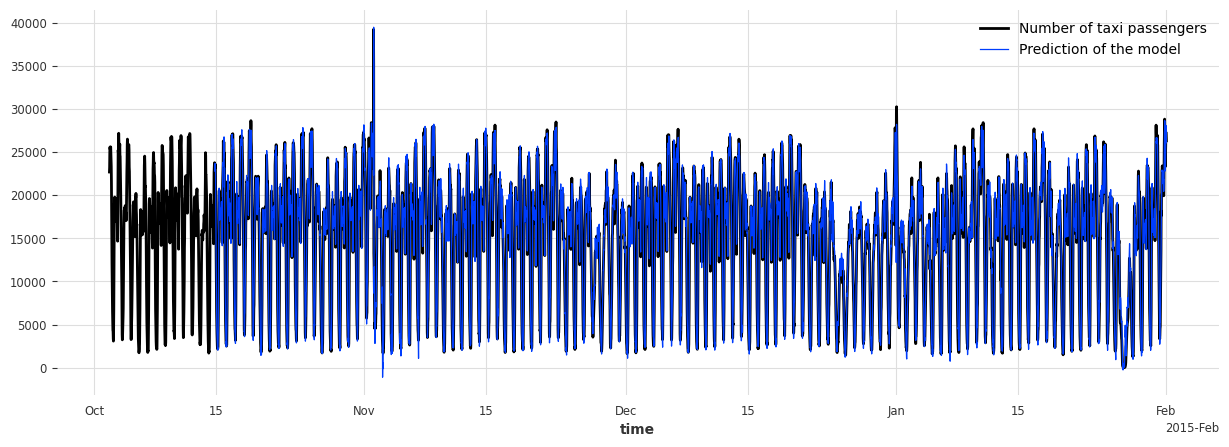

In [39]:
print(
    f"On testing set -> MAE: {mae(model_forecasting, s_taxi_test)}, RMSE:{rmse(model_forecasting, s_taxi_test)}"
)

fig, ax = plt.subplots(figsize=(15,5))
s_taxi_test.plot(label="Number of taxi passengers")
model_forecasting.plot(label="Prediction of the model", linewidth=0.9)
plt.show()

In [40]:
metric_names = ["AUC_ROC", "AUC_PR"]
metric_data = []
for metric_name in metric_names:
    metric_data.append(
        anomaly_model.eval_metric(
            anomalies=series_taxi_anomalies,
            series=s_taxi_test,
            start=START,
            metric=metric_name
        )
    )
pd.DataFrame(data=metric_data, index=metric_names).T

,AUC_ROC,AUC_PR
Norm (ord=1)_w=1,0.658074,0.215601
WassersteinScorer_w=24,0.884915,0.609469
WassersteinScorer_w=48,0.950035,0.687788


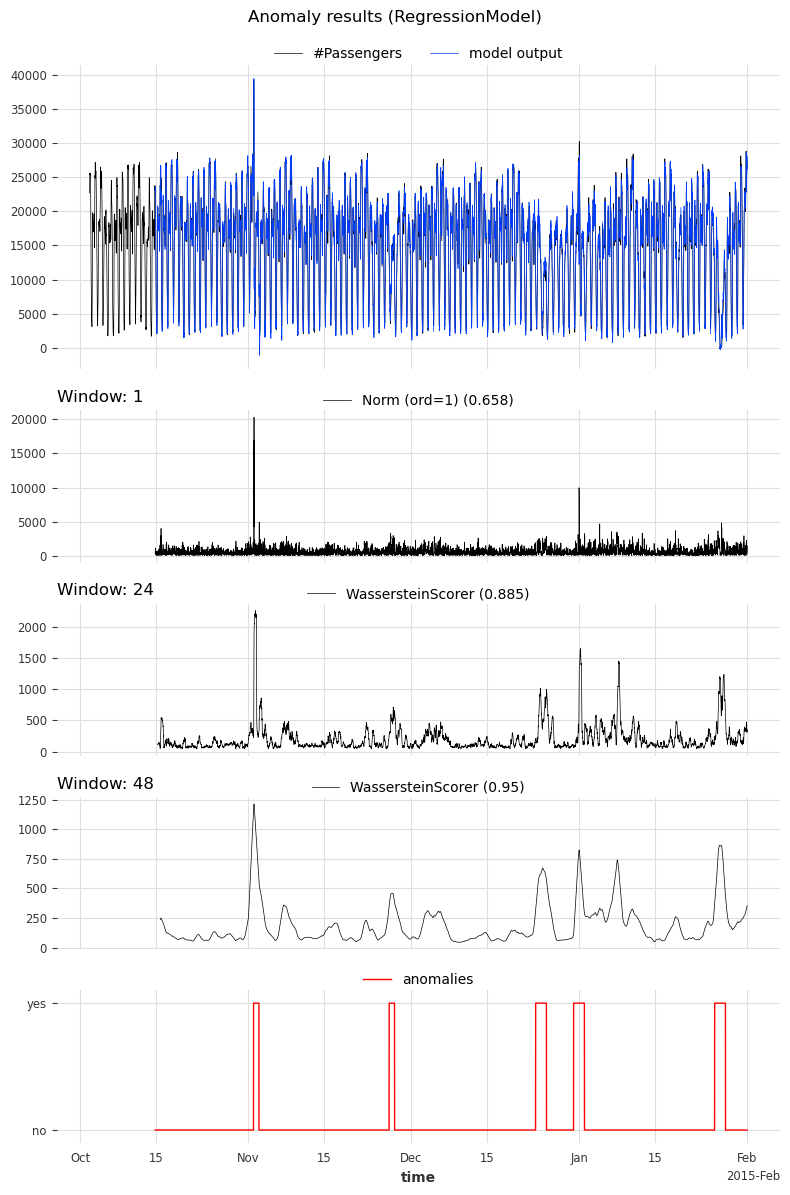

In [41]:
anomaly_model.show_anomalies(
    series=s_taxi_test,
    anomalies=series_taxi_anomalies[pred_start:],
    start=START,
    metric="AUC_ROC"
)

In [42]:
from darts.ad.detectors import QuantileDetector

contamination = 0.95
detector = QuantileDetector(high_quantile=contamination)

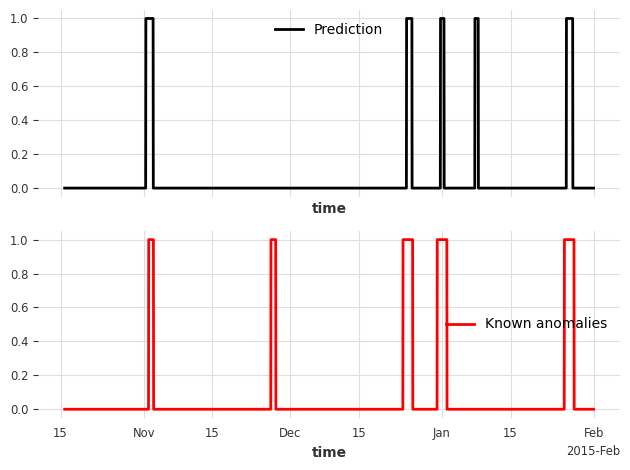

In [43]:
best_anomaly_score = anomaly_scores[-1]

anomaly_pred = detector.fit_detect(series=best_anomaly_score)

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True)
anomaly_pred.plot(label="Prediction", ax=ax1)
series_taxi_anomalies[anomaly_pred.start_time() :].plot(
    label="Known anomalies", ax=ax2, color="red"
)
fig.tight_layout()

In [44]:
for metric_name in ["accuracy", "precision", "recall", "f1"]:
    metric_val = detector.eval_metric(
        pred_scores=best_anomaly_score,
        anomalies=series_taxi_anomalies,
        window=full_day,
        metric=metric_name
    )
    print(metric_name + f": {metric_val:.2f}/1")

accuracy: 0.91/1
precision: 0.76/1
recall: 0.32/1
f1: 0.45/1


In [45]:
windows = [1, half_a_day, full_day]
scorer_names = [f"{scorer}_{w}" for scorer, w in zip(anomaly_model.scorers, windows)]

metric_data = {"AUC_ROC": [], "AUC_PR": []}
for metric_name in metric_data:
    metric_data[metric_name] = eval_metric_from_scores(
        anomalies=series_taxi_anomalies,
        pred_scores=anomaly_scores,
        window=windows,
        metric=metric_name
    )
pd.DataFrame(index=scorer_names, data=metric_data)

,AUC_ROC,AUC_PR
Norm (ord=1)_1,0.658074,0.215601
WassersteinScorer_24,0.884915,0.609469
WassersteinScorer_48,0.950035,0.687788


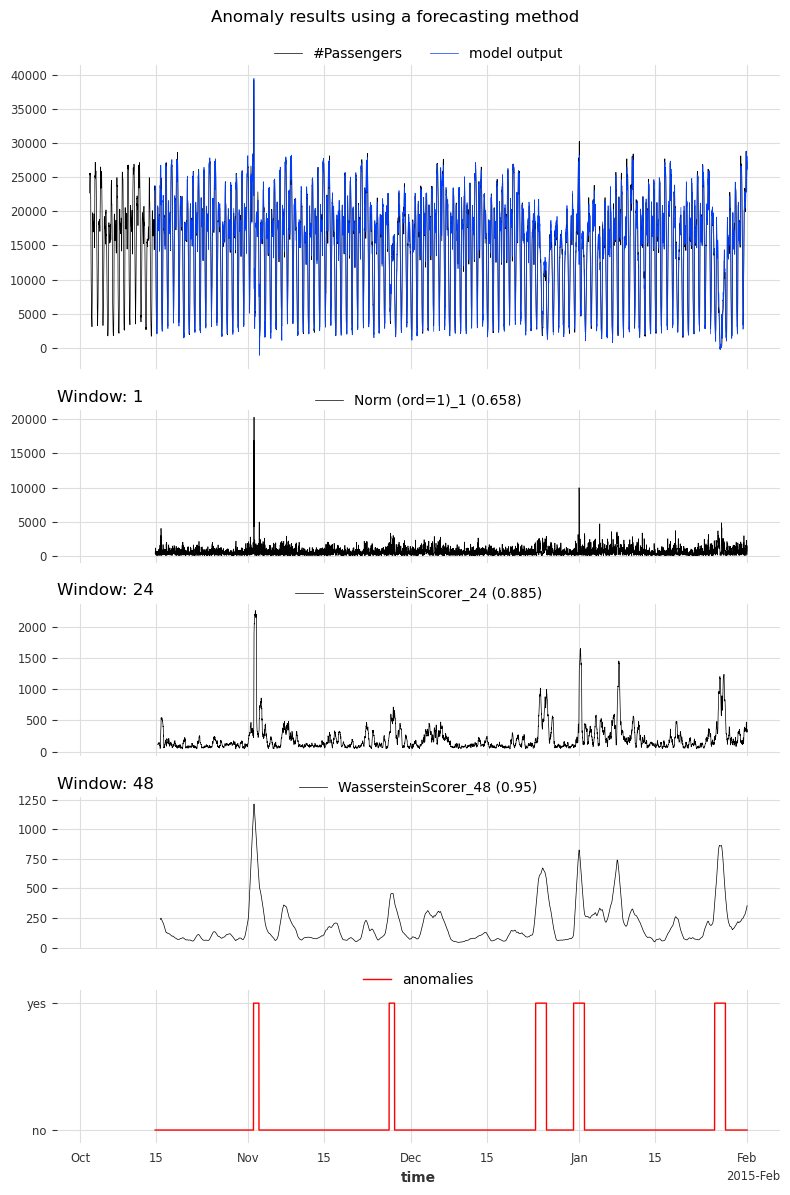

In [46]:
show_anomalies_from_scores(
    series=s_taxi_test,
    anomalies=series_taxi_anomalies[pred_start:],
    pred_scores=anomaly_scores,
    pred_series=model_forecasting,
    window=windows,
    title="Anomaly results using a forecasting method",
    names_of_scorers=scorer_names,
    metric="AUC_ROC"
)

In [ ]:
def plot_anom_eval(selected_anomaly, delta_plotted_days):
    one_day = series_taxi.freq * 24 * 2
    anomaly_date = anomalies_day[selected_anomaly][0]
    start = anomaly_date - one_day * delta_plotted_days
    end = anomaly_date + one_day * delta_plotted_days

    series_taxi[start:end].plot(
        label="Number of Taxi passengers", color="#6464ff", linewidth=0.8
    )
    model_forecasting[start:end].plot(
        label="Model prediction", color="green", linewidth=0.8
    )
    (series_taxi_anomalies[start:end] * 10000).plot(
        label="Known anomaly", color="r", linewidth=0.8
    )
    (Scaler().fit_transform(best_anomaly_score)[start:end] * 10000).plot(
        label="Anomaly score", color="black", linewidth=0.8
    )
    plt.legend(loc="upper center", ncols=2)
    plt.title(selected_anomaly)
    fig.tight_layout()
    plt.show()
for anom_name in anomalies_day:
    plot_anom_eval(anom_name, 3)

In [49]:
pd.DataFrame(index=["State 1", "State 2"], data={"comp1": [0,1], "comp2": [1,0]})

,comp1,comp2
State 1,0,1
State 2,1,0


In [52]:
def generate_data_ex1(randomstate: int):
    np.random.seed(randomstate)

    comp1 = np.expand_dims(np.random.choice(a=[0,1], size=100, p=[0.5, 0.5]), axis=1)
    comp2 = (comp1 == 0).astype(float)
    vals = np.concatenate([comp1, comp2], axis=1)
    return vals

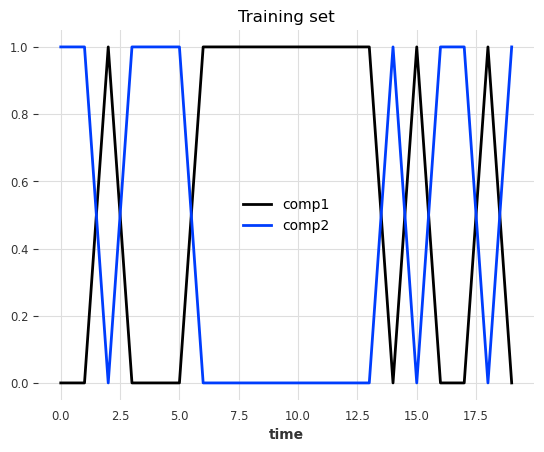

In [53]:
data = generate_data_ex1(randomstate=40)
series_train = TimeSeries.from_values(data, columns=["comp1", "comp2"])

series_train[:20].plot()
plt.title("Training set")
plt.show()

In [61]:
# inject anomalies in test timeseries
data = generate_data_ex1(randomstate=3)

# 2 anomalies per type
# anom 1: random value one compomenet
data[20:21, 0] = 2
data[30:32, 1] = 2

# anom 2: shift both components (+/- 1 for both components)
data[45:47, :] += 1
data[60:64, :] -= 1

# anom 3: switch one value to the other
data[75:82, 0] = data[75:82, 1]
data[90:96, 1] = data[90:96, 0]

series_test = TimeSeries.from_values(data, columns=["component1", "component2"])

anomalies = ~((data == [0,1]).all(axis=1) | (data == [1,0]).all(axis=1))
anomalies = TimeSeries.from_times_and_values(times=series_test.time_index, values=anomalies, columns=["is_anomaly"])

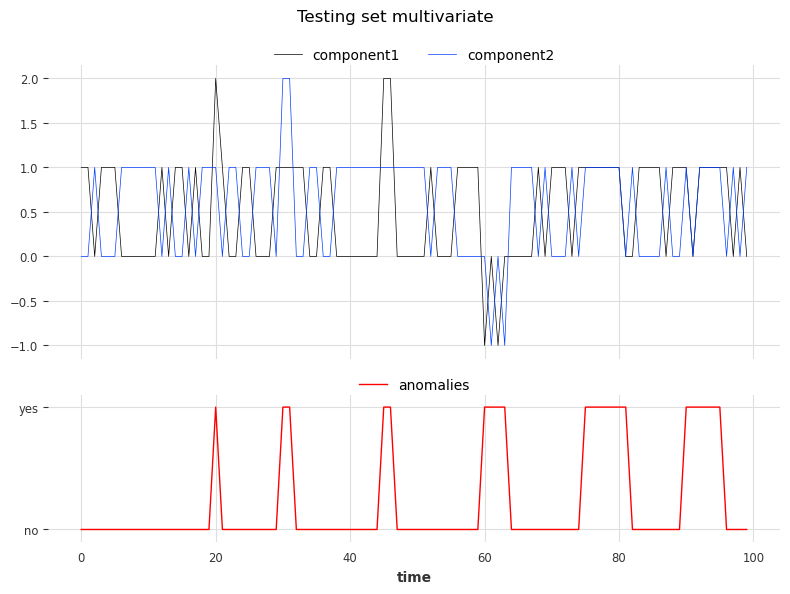

In [62]:
show_anomalies_from_scores(
    series=series_test, anomalies=anomalies, title="Testing set multivariate"
)

In [63]:
# k = 2 because we know the datatset only has two valid states: 0 or 1
# window is the same as lag for regression models; it defines how many timesteps ahead to look.
# in this case we know we only need to look ahead one timestep.
Kmeans_scorer = KMeansScorer(k=2, window=1, component_wise=False)
Kmeans_scorer.fit(series_train)

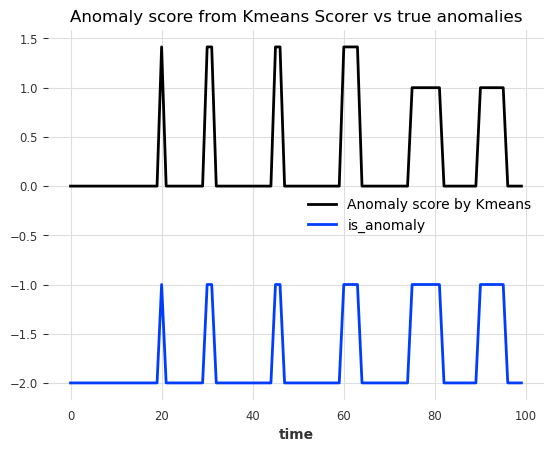

In [64]:
anomaly_score = Kmeans_scorer.score(series_test)

anomaly_score.plot(label="Anomaly score by Kmeans")
(anomalies - 2).plot()
plt.title("Anomaly score from Kmeans Scorer vs true anomalies")
plt.show()

In [65]:
for metric_name in ["AUC_ROC", "AUC_PR"]:
    metric_val = Kmeans_scorer.eval_metric(anomalies, series_test, metric=metric_name)
    print(metric_name + f": {metric_val}")

AUC_ROC: 1.0
AUC_PR: 1.0


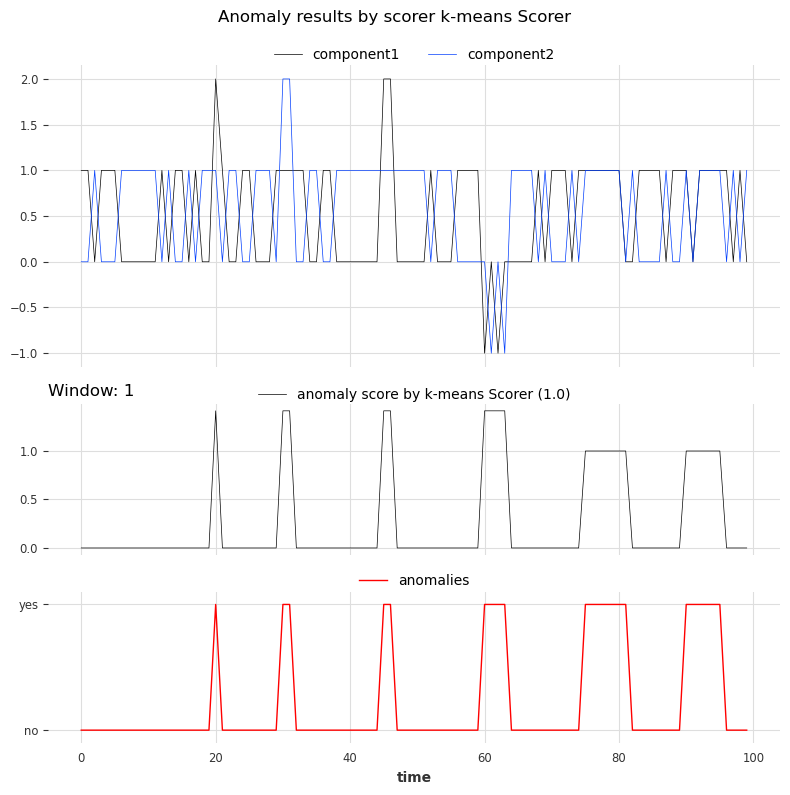

In [66]:
Kmeans_scorer.show_anomalies(series=series_test, anomalies=anomalies, metric="AUC_ROC")

In [67]:
def generate_data_ex2(start_val: int, random_state: int):
    np.random.seed(random_state)
    vals = np.zeros(100)
    vals[0] = start_val

    diffs = np.random.choice(a=[-1, 1], p=[0.5, 0.5], size=len(vals) - 1)
    for i in range(1, len(vals)):
        vals[i] = vals[i - 1] + diffs[i - 1]
        if vals[i] > 3:
            vals[i] = 3
        elif vals[i] < 0:
            vals[i] = 0
    return vals

Text(0.5, 1.0, 'Training set')

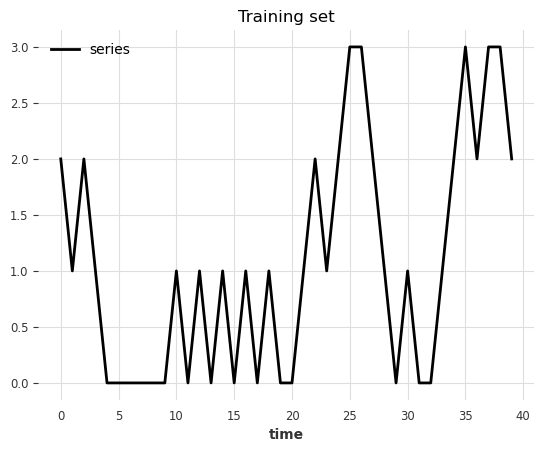

In [68]:
data = generate_data_ex2(start_val=2, random_state=1)
series_train = TimeSeries.from_values(data, columns=["series"])

series_train[:40].plot()
plt.title("Training set")

In [70]:
data = generate_data_ex2(start_val=1, random_state=3)

# 3 anomalies per type
# anom 1: sudden shift between state 0 to state 2 without passing by value 1
data[23] = 3
data[44] = 3
data[91] = 0

# anom 2: having consecutive timestamps w/ value 1 or 2
data[3:5] = 2
data[17:19] = 1
data[62:65] = 2

series_test = TimeSeries.from_values(data, columns=["series"])

diffs = np.abs(data[1:] - data[:-1])
anomalies = ~((diffs == 1) | ((diffs == 0) & np.isin(data[1:], [0,3])))
anomalies = np.concatenate([[False], anomalies]).astype(int)

anomalies = TimeSeries.from_times_and_values(
    series_test.time_index, anomalies, columns=["is_anomaly"]
)

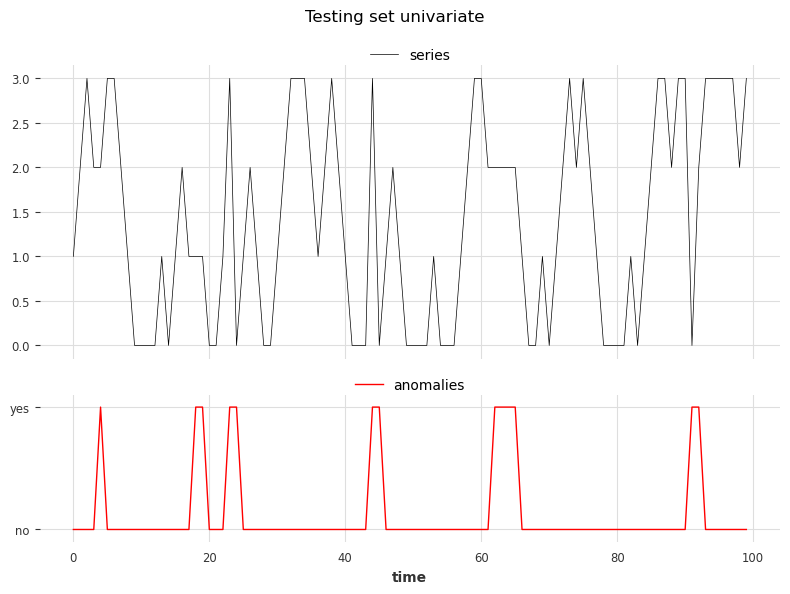

In [71]:
show_anomalies_from_scores(
    series=series_test, anomalies=anomalies, title="Testing set univariate"
)

In [72]:
windows = [1,2]
Kmeans_scorer_w1 = KMeansScorer(k=4, window=windows[0])
Kmeans_scorer_w2 = KMeansScorer(k=8, window=windows[1], window_agg=False)


In [74]:
scores_all = []
metric_data = {"AUC_ROC": [], "AUC_PR": []}
for model, window in zip([Kmeans_scorer_w1, Kmeans_scorer_w2], windows):
    model.fit(series_train)
    scores=model.score(series_test)
    scores_all.append(scores)

    for metric_name in metric_data:
        metric_data[metric_name].append(
            eval_metric_from_scores(
                anomalies=anomalies,
                pred_scores=scores,
                metric=metric_name
            )
        )
pd.DataFrame(data=metric_data, index=["w_1", "w_2"])

,AUC_ROC,AUC_PR
w_1,0.460212,0.123077
w_2,1.000000,1.000000


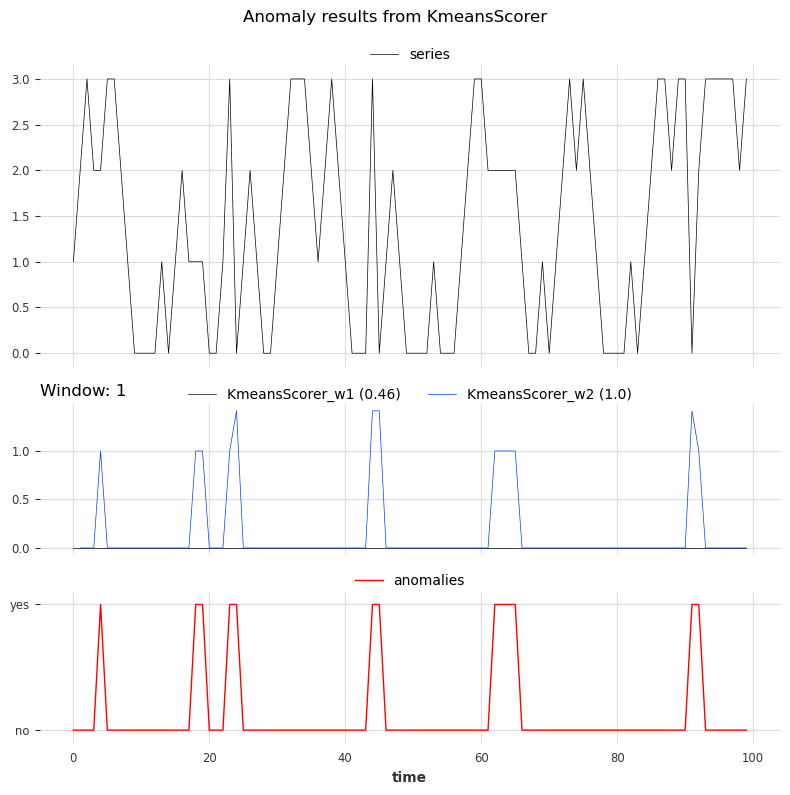

In [75]:
show_anomalies_from_scores(
    series=series_test,
    anomalies=anomalies,
    pred_scores=scores_all,
    names_of_scorers=["KmeansScorer_w1", "KmeansScorer_w2"],
    metric="AUC_ROC",
    title="Anomaly results from KmeansScorer"
)